In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/smart_parking_usage_occupancy_analytics.csv')
display(df.head())

,parking_id,zone,date_time,total_slots,occupied_slots,avg_parking_duration_minutes,vehicle_type,entry_count,exit_count,parking_fee_collected,violation_reported,occupancy_rate_percent
0,1,Mall,2024-01-01 00:00:00,191,112,170,Car,65,86,4268.46,Yes,58.64
1,2,Hospital,2024-01-01 01:00:00,169,22,96,Car,104,100,2791.18,No,13.02
2,3,Office,2024-01-01 02:00:00,215,105,91,Bike,55,82,3603.45,No,48.84
3,4,Hospital,2024-01-01 03:00:00,230,230,228,Bike,102,51,4490.34,No,100.00
4,5,Hospital,2024-01-01 04:00:00,110,247,218,SUV,13,7,4513.62,No,224.55


In [19]:
df = pd.read_csv('/content/smart_parking_usage_occupancy_analytics.csv')
df['datetime'] = pd.to_datetime(df['date_time'])
df = df.sort_values('datetime').set_index('datetime')

# Extract time-based features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear
df['month'] = df.index.month
# Add is_weekend feature (Saturday=5, Sunday=6)
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Drop the original 'date_time' column as it's now handled by the index and new features
df = df.drop(columns=['date_time'])

display(df.head())

,parking_id,zone,total_slots,occupied_slots,avg_parking_duration_minutes,vehicle_type,entry_count,exit_count,parking_fee_collected,violation_reported,occupancy_rate_percent,hour,day_of_week,day_of_year,month,is_weekend
datetime,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,1,Mall,191,112,170,Car,65,86,4268.46,Yes,58.64,0,0,1,1,0
2024-01-01 01:00:00,2,Hospital,169,22,96,Car,104,100,2791.18,No,13.02,1,0,1,1,0
2024-01-01 02:00:00,3,Office,215,105,91,Bike,55,82,3603.45,No,48.84,2,0,1,1,0
2024-01-01 03:00:00,4,Hospital,230,230,228,Bike,102,51,4490.34,No,100.00,3,0,1,1,0
2024-01-01 04:00:00,5,Hospital,110,247,218,SUV,13,7,4513.62,No,224.55,4,0,1,1,0


Next, let's check the data types and look for any missing values.

In [4]:
df.info()
print("\nMissing values:")
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parking_id                    2800 non-null   int64  
 1   zone                          2800 non-null   object 
 2   date_time                     2800 non-null   object 
 3   total_slots                   2800 non-null   int64  
 4   occupied_slots                2800 non-null   int64  
 5   avg_parking_duration_minutes  2800 non-null   int64  
 6   vehicle_type                  2800 non-null   object 
 7   entry_count                   2800 non-null   int64  
 8   exit_count                    2800 non-null   int64  
 9   parking_fee_collected         2800 non-null   float64
 10  violation_reported            2800 non-null   object 
 11  occupancy_rate_percent        2800 non-null   float64
dtypes: float64(2), int64(6), object(4)
memory usage: 262.6+ KB

Mi

,0
parking_id,0
zone,0
date_time,0
total_slots,0
occupied_slots,0
avg_parking_duration_minutes,0
vehicle_type,0
entry_count,0
exit_count,0
parking_fee_collected,0


Now, let's encode the categorical feature `vehicle_type` using one-hot encoding, as it will be used as an input to the LSTM model.

In [5]:
df = pd.get_dummies(df, columns=['vehicle_type'], prefix='vehicle')
display(df.head())

,parking_id,zone,date_time,total_slots,occupied_slots,avg_parking_duration_minutes,entry_count,exit_count,parking_fee_collected,violation_reported,occupancy_rate_percent,vehicle_Bike,vehicle_Car,vehicle_Electric,vehicle_SUV
0,1,Mall,2024-01-01 00:00:00,191,112,170,65,86,4268.46,Yes,58.64,False,True,False,False
1,2,Hospital,2024-01-01 01:00:00,169,22,96,104,100,2791.18,No,13.02,False,True,False,False
2,3,Office,2024-01-01 02:00:00,215,105,91,55,82,3603.45,No,48.84,True,False,False,False
3,4,Hospital,2024-01-01 03:00:00,230,230,228,102,51,4490.34,No,100.00,True,False,False,False
4,5,Hospital,2024-01-01 04:00:00,110,247,218,13,7,4513.62,No,224.55,False,False,False,True


Let's encode the remaining categorical features: `zone` and `violation_reported`.

In [6]:
df = pd.get_dummies(df, columns=['zone'], prefix='zone')
df['violation_reported'] = df['violation_reported'].map({'Yes': 1, 'No': 0})
display(df.head())

,parking_id,date_time,total_slots,occupied_slots,avg_parking_duration_minutes,entry_count,exit_count,parking_fee_collected,violation_reported,occupancy_rate_percent,vehicle_Bike,vehicle_Car,vehicle_Electric,vehicle_SUV,zone_Commercial,zone_Hospital,zone_Mall,zone_Office,zone_Residential
0,1,2024-01-01 00:00:00,191,112,170,65,86,4268.46,1,58.64,False,True,False,False,False,False,True,False,False
1,2,2024-01-01 01:00:00,169,22,96,104,100,2791.18,0,13.02,False,True,False,False,False,True,False,False,False
2,3,2024-01-01 02:00:00,215,105,91,55,82,3603.45,0,48.84,True,False,False,False,False,False,False,True,False
3,4,2024-01-01 03:00:00,230,230,228,102,51,4490.34,0,100.00,True,False,False,False,False,True,False,False,False
4,5,2024-01-01 04:00:00,110,247,218,13,7,4513.62,0,224.55,False,False,False,True,False,True,False,False,False


Now that all features are encoded, let's define the input features (X) and target variables (y) for our LSTM model. We'll use 'available_slots' (calculated from `total_slots` and `occupied_slots`) and `parking_fee_collected` as our target outputs.

In [9]:
# Calculate 'available_slots' as a target variable
df['available_slots'] = df['total_slots'] - df['occupied_slots']

# Define target variables
target_cols = ['available_slots', 'parking_fee_collected']

# Define features (all columns except parking_id, date_time, total_slots, occupied_slots, and target_cols)
# Explicitly exclude 'date_time' from features as its information is captured in other time-based features
exclude_cols = ['parking_id', 'total_slots', 'occupied_slots', 'date_time'] + target_cols
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df[target_cols]

display(X.head())
display(y.head())

,avg_parking_duration_minutes,entry_count,exit_count,violation_reported,occupancy_rate_percent,vehicle_Bike,vehicle_Car,vehicle_Electric,vehicle_SUV,zone_Commercial,zone_Hospital,zone_Mall,zone_Office,zone_Residential
0,170,65,86,1,58.64,False,True,False,False,False,False,True,False,False
1,96,104,100,0,13.02,False,True,False,False,False,True,False,False,False
2,91,55,82,0,48.84,True,False,False,False,False,False,False,True,False
3,228,102,51,0,100.00,True,False,False,False,False,True,False,False,False
4,218,13,7,0,224.55,False,False,False,True,False,True,False,False,False


,available_slots,parking_fee_collected
0,79,4268.46
1,147,2791.18
2,110,3603.45
3,0,4490.34
4,-137,4513.62


Before feeding the data into the LSTM model, we need to scale the features and target variables. LSTM models are sensitive to the scale of the input data, so we'll use `MinMaxScaler`.

In [10]:
# Initialize MinMax Scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale features (X)
X_scaled = x_scaler.fit_transform(X)

# Scale target variables (y)
y_scaled = y_scaler.fit_transform(y)

# Reshape X for LSTM input (samples, timesteps, features)
# For a single timestep, we just add a new dimension
X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

print("Shape of X_reshaped:", X_reshaped.shape)
print("Shape of y_scaled:", y_scaled.shape)

Shape of X_reshaped: (2800, 1, 14)
Shape of y_scaled: (2800, 2)


Now, let's split our scaled data into training and testing sets. This is a crucial step to evaluate the model's performance on unseen data. We'll then define the LSTM model architecture, compile it, and proceed with training.

Now, let's experiment with different `batch_size` values and tune the LSTM architecture. We'll define variables for `lstm_units`, `dropout_rate`, `epochs`, and `batch_size` to easily adjust them for our experiments.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 1, 100)         │        46,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,602 (494.54 KB)

 Trainable params: 126,602 (494.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1822 - val_loss: 0.0741
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0732 - val_loss: 0.0639
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0669 - val_loss: 0.0609
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0633 - val_loss: 0.0567
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0595 - val_loss: 0.0520
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0538 - val_loss: 0.0481
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0512 - val_loss: 0.0483
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0500 - val_loss: 0.0472
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0503 - val_loss: 0.0482
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0500 - val_loss: 0.0466
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0494 - val_loss: 0.0468
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0488 - val_

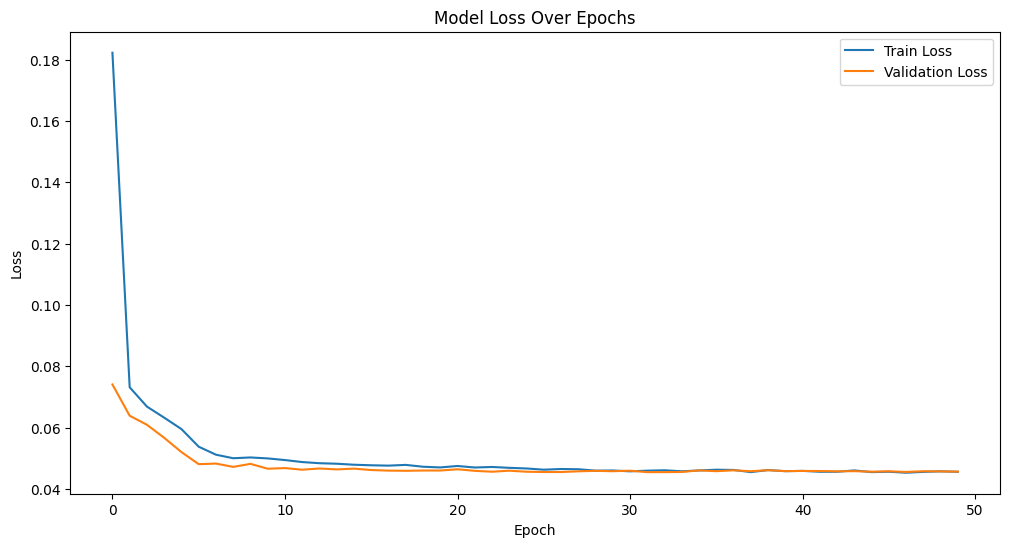

In [38]:
# Define hyperparameters for tuning
lstm_units = 100
dropout_rate = 0.2
epochs = 50
batch_size = 64 # Experiment with values like 16, 64, 128

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=lstm_units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(dropout_rate))
model.add(LSTM(units=lstm_units, return_sequences=False))
model.add(Dropout(dropout_rate))
model.add(Dense(units=y_train.shape[1])) # Output layer for 2 target variables

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Now that the model is trained, let's evaluate its performance on the test set. We'll make predictions, inverse scale them to get the original values, and then calculate Mean Squared Error (MSE) and R2 score for both `available_slots` and `parking_fee_collected`. Finally, we'll visualize the actual vs. predicted values.

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
--- Metrics for available_slots ---
Mean Squared Error: 968.0525
R2 Score: 0.8995




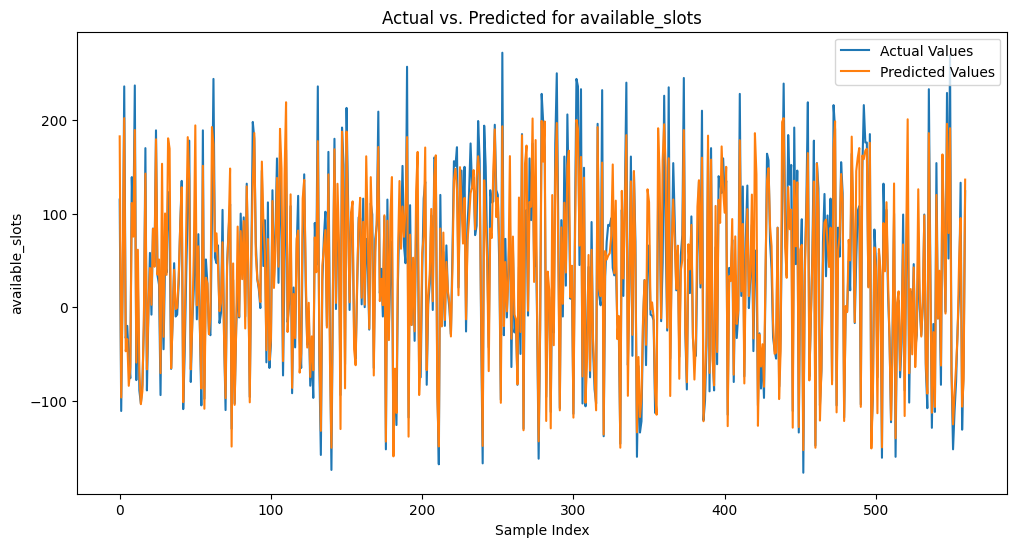

--- Metrics for parking_fee_collected ---
Mean Squared Error: 2170868.3094
R2 Score: -0.0087




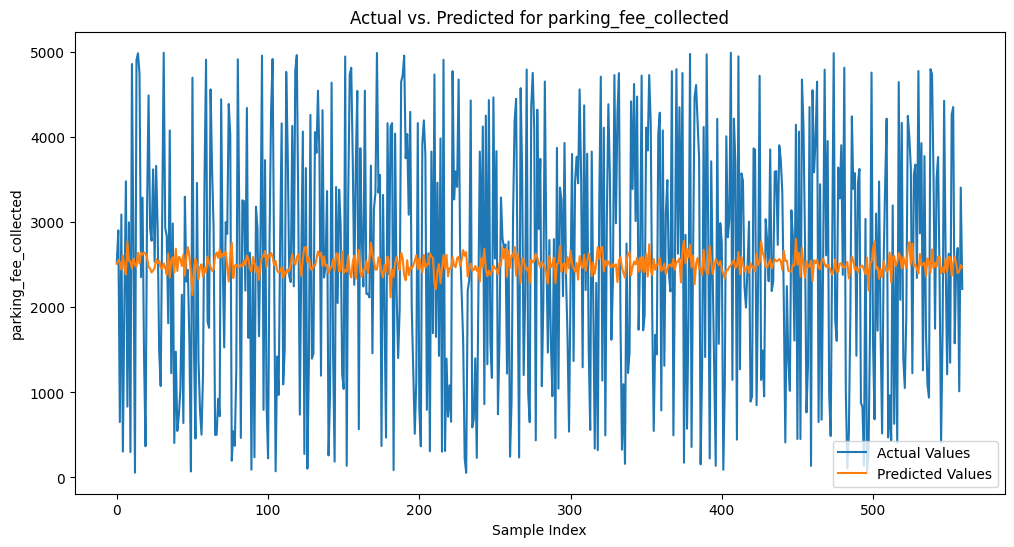

In [39]:
# Make predictions on the test set
y_pred_scaled = model.predict(X_test)

# Inverse transform the scaled predictions and actuals to original scale
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_orig = y_scaler.inverse_transform(y_test)

# Calculate evaluation metrics for each target variable
metrics = {}
target_cols = ['available_slots', 'parking_fee_collected'] # Assuming this order from y

for i, col in enumerate(target_cols):
    mse = mean_squared_error(y_test_orig[:, i], y_pred[:, i])
    r2 = r2_score(y_test_orig[:, i], y_pred[:, i])
    metrics[col] = {'MSE': mse, 'R2': r2}

    print(f"--- Metrics for {col} ---")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R2 Score: {r2:.4f}")
    print("\n")

    # Plotting Actual vs. Predicted values
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_orig[:, i], label='Actual Values')
    plt.plot(y_pred[:, i], label='Predicted Values')
    plt.title(f'Actual vs. Predicted for {col}')
    plt.xlabel('Sample Index')
    plt.ylabel(col)
    plt.legend()
    plt.show()

In [40]:
# Save the trained model
model.save('lstm_parking_model.keras')
print("Model saved to lstm_parking_model.keras")

Model saved to lstm_parking_model.keras


In [16]:
# Initialize MinMax Scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale features (X)
X_scaled = x_scaler.fit_transform(X)

# Scale target variables (y)
y_scaled = y_scaler.fit_transform(y)

# Reshape X for LSTM input (samples, timesteps, features)
# For a single timestep, we just add a new dimension
X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

print("Shape of X_reshaped:", X_reshaped.shape)
print("Shape of y_scaled:", y_scaled.shape)

Shape of X_reshaped: (2800, 1, 14)
Shape of y_scaled: (2800, 2)
